# Recurrent Neural Networks — Full Explanation and Backpropagation Derivation

## Why do we need RNNs?

A traditional **Feedforward Neural Network (FNN)** processes a single input $x$ and produces a single output $\hat{y}$:

$$
\hat{y} = f(x; \Theta).
$$

However, many tasks require processing **sequences**:
- Sentences, where **word order** matters.
- Time series, where each prediction depends on **past data**.
- Speech or audio, where each frame is **correlated** with earlier frames.

A plain FNN has **no memory**: every input is independent.  
So it **cannot model dependencies across time**.

**Solution:** add **memory** by feeding each step’s **hidden state** to the next step — this is the essence of a **Recurrent Neural Network (RNN)**.

## Basic idea: single-layer RNN

An RNN processes a sequence:

$$
x_1, x_2, \dots, x_T.
$$

It maintains a hidden state $h_t$ which stores **context** from earlier inputs.

## Forward pass equations (per step)

**Trainable parameters:**
- $W_{xh}$ — weights from input to hidden
- $W_{hh}$ — weights from previous hidden to new hidden (recurrence)
- $b_h$ — bias for hidden
- $W_{hy}$ — weights from hidden to output
- $b_y$ — output bias

At each time step $t$:

$$
a_t = W_{xh} x_t + W_{hh} h_{t-1} + b_h,
\quad
h_t = \tanh(a_t),
\quad
\hat{y}_t = W_{hy} h_t + b_y.
$$

The same weights are **shared across all steps**.

## Example — $T = 3$

Suppose:
- Sequence: $x_1 = 1$, $x_2 = 2$, $x_3 = 3$  
- Initial hidden state: $h_0 = 0$  
- $W_{xh} = 0.5$, $W_{hh} = 0.8$, $b_h = 0$

Then:

$$
a_1 = 0.5 \times 1 + 0.8 \times 0 = 0.5, \quad h_1 = \tanh(0.5) \approx 0.462
$$

$$
a_2 = 0.5 \times 2 + 0.8 \times 0.462 = 1.0 + 0.37 = 1.37, \quad h_2 = \tanh(1.37) \approx 0.879
$$

$$
a_3 = 0.5 \times 3 + 0.8 \times 0.879 = 1.5 + 0.703 = 2.203, \quad h_3 = \tanh(2.203) \approx 0.975.
$$

## Loss for a sequence

Assume a squared loss at each step:

$$
L_t = \frac{1}{2} (\hat{y}_t - y_t)^2.
$$

Total loss:

$$
L = \sum_{t=1}^T L_t.
$$

## Backpropagation Through Time (BPTT)

**Key:** Each hidden state $h_t$ affects:
1. The output $\hat{y}_t$ directly.
2. The next hidden state $h_{t+1}$ indirectly.

This means the gradient must flow through **both paths**.

**Output layer:**  

$$
\frac{\partial L_t}{\partial W_{hy}} = (\hat{y}_t - y_t) h_t^T,
\quad
\frac{\partial L_t}{\partial b_y} = (\hat{y}_t - y_t).
$$

**Hidden state:**  

$$
\frac{\partial L_t}{\partial h_t} = W_{hy}^T (\hat{y}_t - y_t).
$$

But $h_t$ affects $h_{t+1}$ too:

$$
a_{t+1} = W_{xh} x_{t+1} + W_{hh} h_t + b_h.
$$

So:

$$
\frac{\partial a_{t+1}}{\partial h_t} = W_{hh}.
$$

So the total gradient flowing back to $h_t$:

$$
\frac{\partial L}{\partial h_t} =
\underbrace{W_{hy}^T (\hat{y}_t - y_t)}_{\text{direct}}
+ \underbrace{W_{hh}^T \frac{\partial L}{\partial a_{t+1}}}_{\text{through next step}}.
$$

The local activation derivative:

$$
\frac{\partial h_t}{\partial a_t} = 1 - h_t^2.
$$

So:

$$
\frac{\partial L}{\partial a_t} =
\frac{\partial L}{\partial h_t} \odot (1 - h_t^2).
$$

**Input-to-hidden:**

$$
\frac{\partial L}{\partial W_{xh}} = \sum_{t=1}^T \frac{\partial L}{\partial a_t} x_t^T.
$$

**Hidden-to-hidden:**

$$
\frac{\partial L}{\partial W_{hh}} = \sum_{t=1}^T \frac{\partial L}{\partial a_t} h_{t-1}^T.
$$

**Hidden bias:**

$$
\frac{\partial L}{\partial b_h} = \sum_{t=1}^T \frac{\partial L}{\partial a_t}.
$$

## What is BPTT doing?

**Backpropagation Through Time**:
- Unrolls the RNN across time.
- Uses the chain rule step by step.
- Accumulates direct and indirect paths.
- Handles the fact that each hidden state influences future states.

## Summary

**An RNN is just:**
- Reusing the same weights to process sequences of any length.
- Updating a hidden state to act as memory.
- Backpropagating through this chain so the model learns how to balance:
  - New input
  - Past memory

This is **exactly** how real frameworks compute gradients automatically under the hood.

## Next

We’ll:
- Pick a real sequence task (e.g., simple sequence prediction)
- Implement this in **NumPy**
- Train it with full BPTT
- Visualize how it learns temporal dependencies

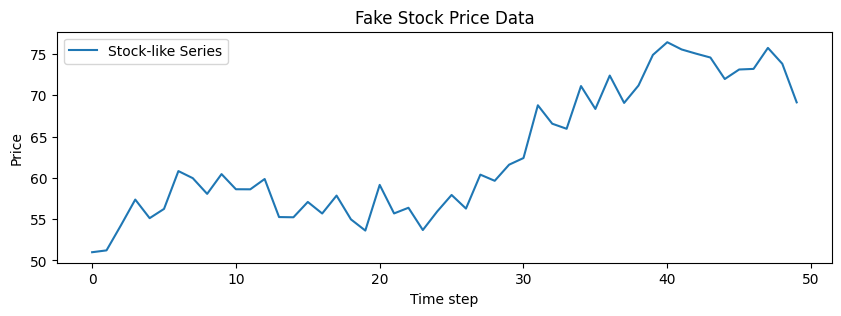

Epoch 0 | MSE Loss: 0.992177
Epoch 200 | MSE Loss: 0.116593
Epoch 400 | MSE Loss: 0.107743
Epoch 600 | MSE Loss: 0.104005
Epoch 800 | MSE Loss: 0.101321
Epoch 1000 | MSE Loss: 0.098957
Epoch 1200 | MSE Loss: 0.096630
Epoch 1400 | MSE Loss: 0.094156
Epoch 1600 | MSE Loss: 0.091360
Epoch 1800 | MSE Loss: 0.088049
Epoch 1999 | MSE Loss: 0.084019


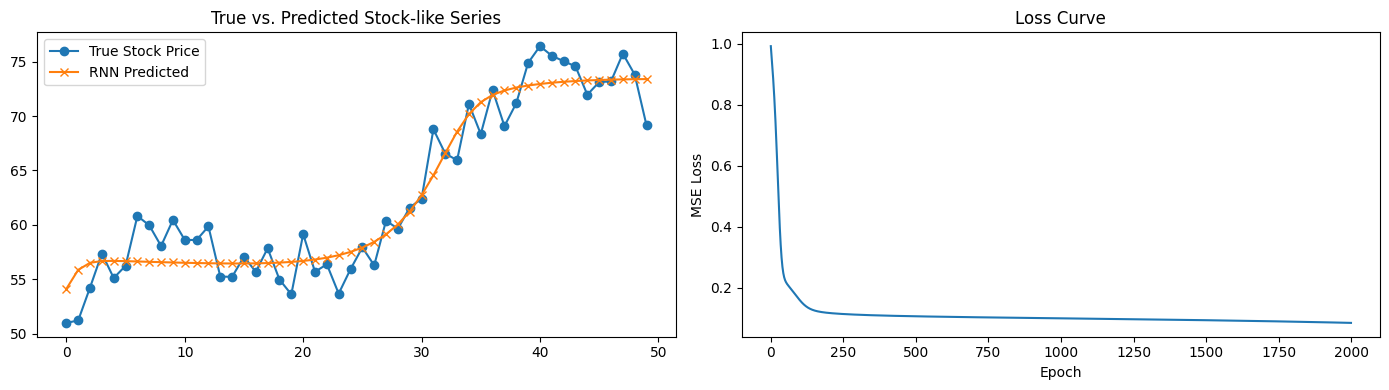

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# --- Fake stock price: trend + noise ---
T = 50
x_seq = np.arange(T)
y_seq = 50 + 0.5 * x_seq + np.sin(0.2 * x_seq) * 5 + np.random.randn(T) * 2
y_seq = y_seq.reshape(-1, 1)  # shape (T, 1)

plt.figure(figsize=(10, 3))
plt.plot(x_seq, y_seq, label="Stock-like Series")
plt.title("Fake Stock Price Data")
plt.xlabel("Time step")
plt.ylabel("Price")
plt.legend()
plt.show()

# --- RNN dimensions ---
input_size = 1
hidden_size = 8
output_size = 1

# --- Initialize ---
W_xh = np.random.randn(hidden_size, input_size) * 0.1
W_hh = np.random.randn(hidden_size, hidden_size) * 0.1
b_h = np.zeros((hidden_size, 1))

W_hy = np.random.randn(output_size, hidden_size) * 0.1
b_y = np.zeros((output_size, 1))

lr = 0.001
epochs = 2000
losses = []

# --- Normalize ---
x_seq_norm = (x_seq - np.mean(x_seq)) / np.std(x_seq)
y_seq_norm = (y_seq - np.mean(y_seq)) / np.std(y_seq)

# --- Train ---
for epoch in range(epochs):

    # Store states
    h = np.zeros((hidden_size, T+1))
    y_hat = np.zeros((output_size, T))

    # Forward pass
    for t in range(T):
        x_t = np.array([[x_seq_norm[t]]])  # shape (1,1)
        a_t = W_xh @ x_t + W_hh @ h[:, [t]] + b_h
        h[:, [t+1]] = np.tanh(a_t)
        y_hat[:, [t]] = W_hy @ h[:, [t+1]] + b_y

    loss = np.mean((y_hat.flatten() - y_seq_norm.flatten())**2)
    losses.append(loss)

    # BPTT
    dW_xh = np.zeros_like(W_xh)
    dW_hh = np.zeros_like(W_hh)
    db_h  = np.zeros_like(b_h)
    dW_hy = np.zeros_like(W_hy)
    db_y  = np.zeros_like(b_y)

    dh_next = np.zeros((hidden_size, 1))

    for t in reversed(range(T)):
        dy = (y_hat[:, [t]] - y_seq_norm[t].reshape(-1, 1))
        dW_hy += dy @ h[:, [t+1]].T
        db_y  += dy

        dh = W_hy.T @ dy + dh_next
        da = dh * (1 - h[:, [t+1]] ** 2)

        x_t = np.array([[x_seq_norm[t]]])
        dW_xh += da @ x_t.T
        dW_hh += da @ h[:, [t]].T
        db_h  += da

        dh_next = W_hh.T @ da

    for param, dparam in zip([W_xh, W_hh, b_h, W_hy, b_y],
                             [dW_xh, dW_hh, db_h, dW_hy, db_y]):
        param -= lr * dparam

    if epoch % 200 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch} | MSE Loss: {loss:.6f}")

# --- Final prediction ---
h_final = np.zeros((hidden_size, T+1))
y_hat_final = np.zeros((output_size, T))

for t in range(T):
    x_t = np.array([[x_seq_norm[t]]])
    a_t = W_xh @ x_t + W_hh @ h_final[:, [t]] + b_h
    h_final[:, [t+1]] = np.tanh(a_t)
    y_hat_final[:, [t]] = W_hy @ h_final[:, [t+1]] + b_y

# Denormalize
y_hat_final_rescaled = y_hat_final.flatten() * np.std(y_seq) + np.mean(y_seq)

# --- 6️⃣ Visualize ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(x_seq, y_seq.flatten(), label="True Stock Price", marker='o')
axes[0].plot(x_seq, y_hat_final_rescaled, label="RNN Predicted", marker='x')
axes[0].set_title("True vs. Predicted Stock-like Series")
axes[0].legend()

axes[1].plot(losses)
axes[1].set_title("Loss Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")

plt.tight_layout()
plt.show()